In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv(r"C:\Users\kuayu\Downloads\Python_Diwali_Sales_Analysis\Diwali_Sales_Data.csv", encoding='unicode_escape')
# to avoid encoding error, use unicode_escape

In [22]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [15]:
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

In [17]:
df.shape

(11251, 15)

In [24]:
# drop unrelated columns
df.drop(['Status','unnamed1'], inplace = True, axis = 1)

In [30]:
# drop null values in your data
df.dropna(inplace=True)

In [32]:
# change amount column data type
df['Amount'] = df['Amount'].astype('int')

In [34]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610553
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355168
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [58]:
sales_gender = df.groupby(['Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending = False)

# By default, groupby sets the grouping column as index. Using as_index=False keeps it as a normal column.

Text(0.5, 1.0, 'Gender by Sales Amount')

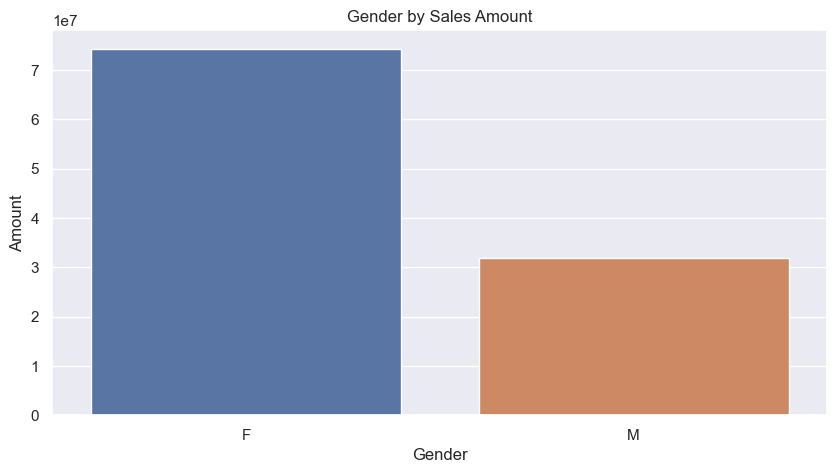

In [104]:
sns.barplot(x = 'Gender', y = 'Amount', data = sales_gender, hue = 'Gender')
plt.title('Gender by Sales Amount')

In [ ]:
# this analysis show females purchased more items than Males

In [61]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [74]:
# Sales_Gender vs Amount bar group

sales_age = df.groupby(['Age Group'])['Amount'].sum().reset_index().sort_values(by='Amount', ascending = False)

Text(0.5, 1.0, 'Age Group by Sales Amount')

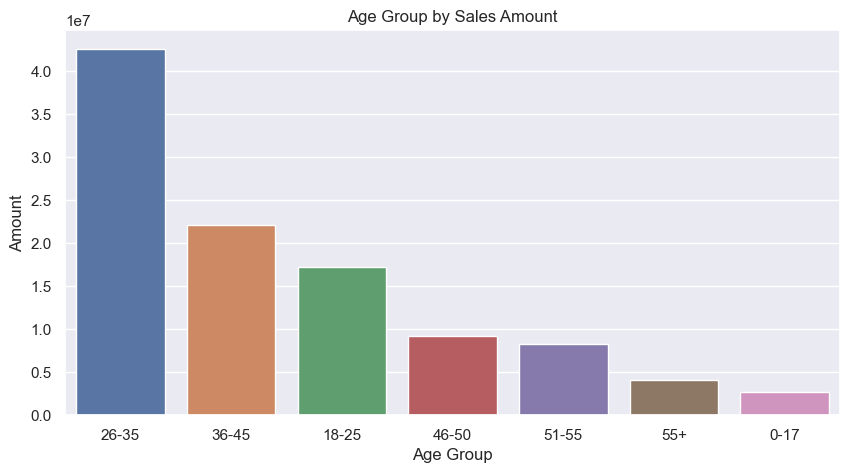

In [107]:
sns.barplot( x = 'Age Group', y = 'Amount', data = sales_age, hue = 'Age Group')
plt.title('Age Group by Sales Amount')

Text(0.5, 1.0, 'Gender & Age Group by Sales Count')

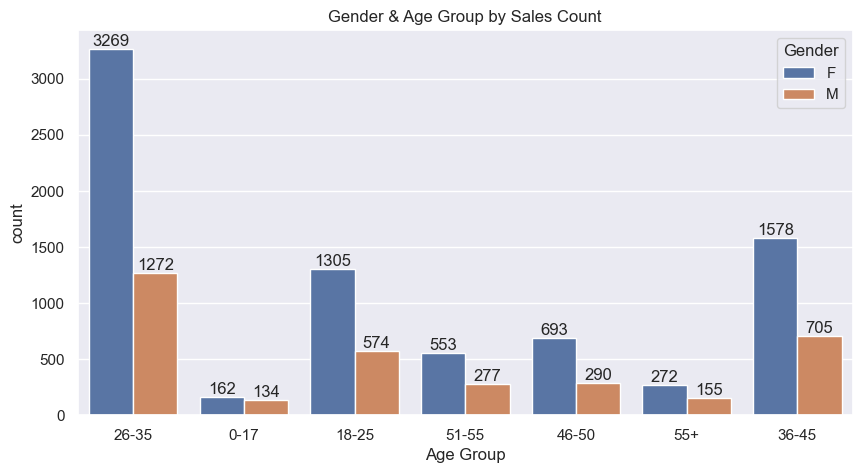

In [108]:
# Gender count

ax = sns.countplot(data = df , x = 'Age Group', hue = 'Gender')

# Add bar labels
for bars in ax.containers:
    ax.bar_label(bars)

plt.title('Gender & Age Group by Sales Count')

In [ ]:
# this analysis show females age group 26-35 doing more purchasing

In [ ]:
State

In [124]:
state_order = df.groupby(['State'])['Orders'].count().reset_index().sort_values(by='Orders', ascending = False).head(10)

Text(0.5, 1.0, 'Top 10 States by Orders Count')

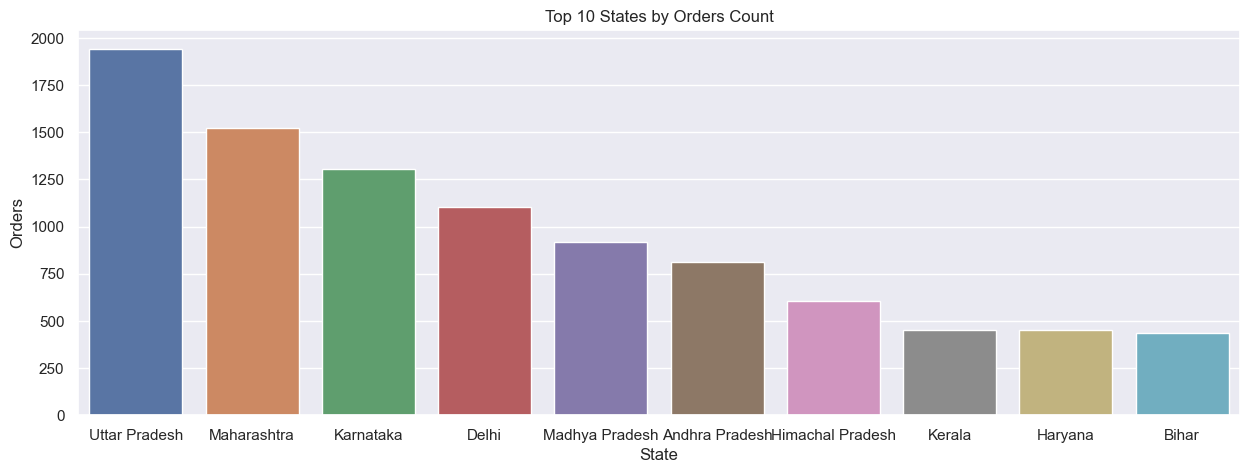

In [133]:
sns.barplot(x = 'State', y = 'Orders', data = state_order, hue ='State')
# resize bar to show value
sns.set(rc={'figure.figsize':(15,5)})
#plt.xticks(rotation=45)
plt.title('Top 10 States by Orders Count')

Text(0.5, 1.0, 'Top 10 States by Sales Amount')

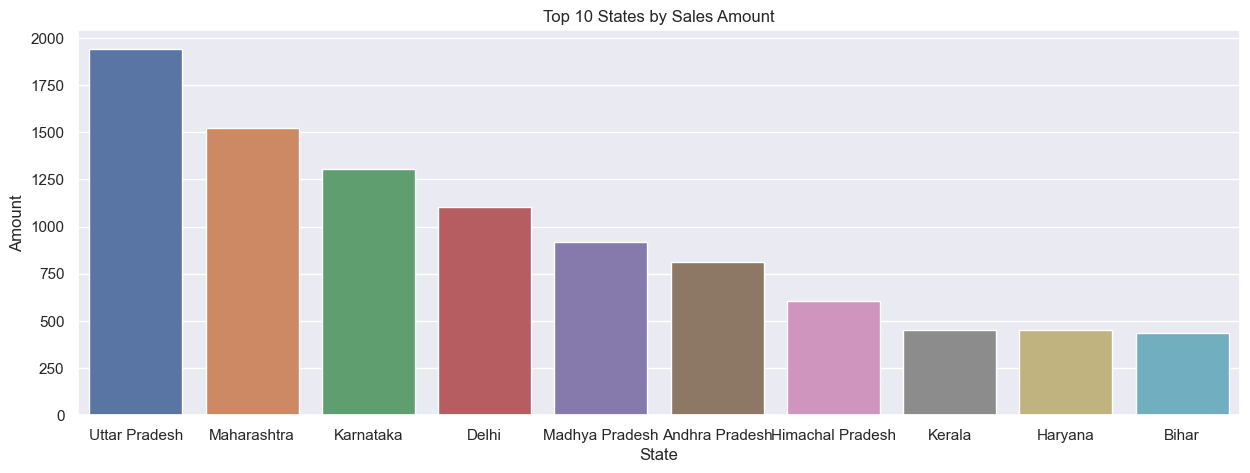

In [135]:
state_amt = df.groupby(['State'])['Amount'].count().reset_index().sort_values(by='Amount', ascending = False).head(10)

sns.barplot(x = 'State', y = 'Amount', data = state_amt, hue ='State')
# resize bar to show value
sns.set(rc={'figure.figsize':(15,5)})
#plt.xticks(rotation=45)
plt.title('Top 10 States by Sales Amount')

Text(0.5, 1.0, 'Married & Gender by Sales Amount')

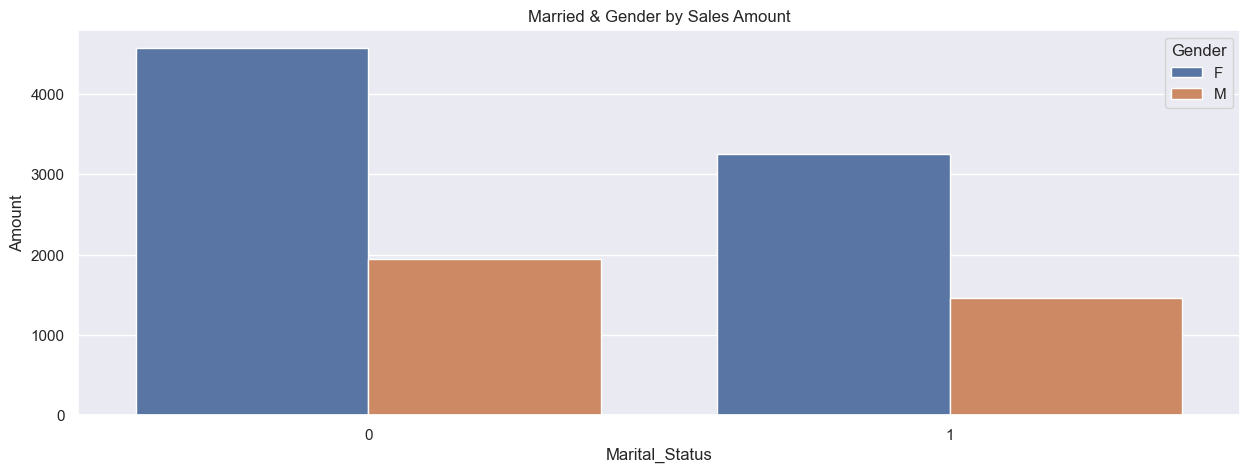

In [141]:
Marital_Status = df.groupby(['Marital_Status','Gender'])['Amount'].count().reset_index().sort_values(by='Amount', ascending = False).head(10)

sns.barplot(x = 'Marital_Status', y = 'Amount', data = Marital_Status, hue ='Gender')
# resize bar to show value
#sns.set(rc={'figure.figsize':(15,5)})
#plt.xticks(rotation=45)
plt.title('Married & Gender by Sales Amount')

In [ ]:
# Married Females doing more transactions

Text(0.5, 1.0, 'Occupation by Sales Amount')

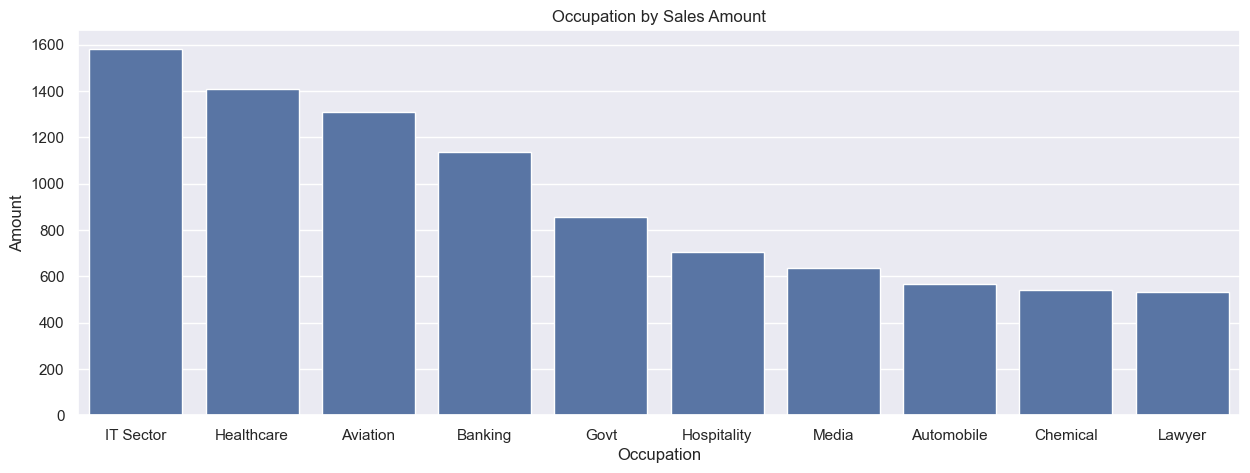

In [149]:
Occupation = df.groupby(['Occupation'])['Amount'].count().reset_index().sort_values(by='Amount', ascending = False).head(10)

sns.barplot(x = 'Occupation', y = 'Amount', data = Occupation)
# resize bar to show value
#sns.set(rc={'figure.figsize':(15,5)})
#plt.xticks(rotation=45)
plt.title('Occupation by Sales Amount')

Text(0.5, 1.0, 'Occupation by Sales Count')

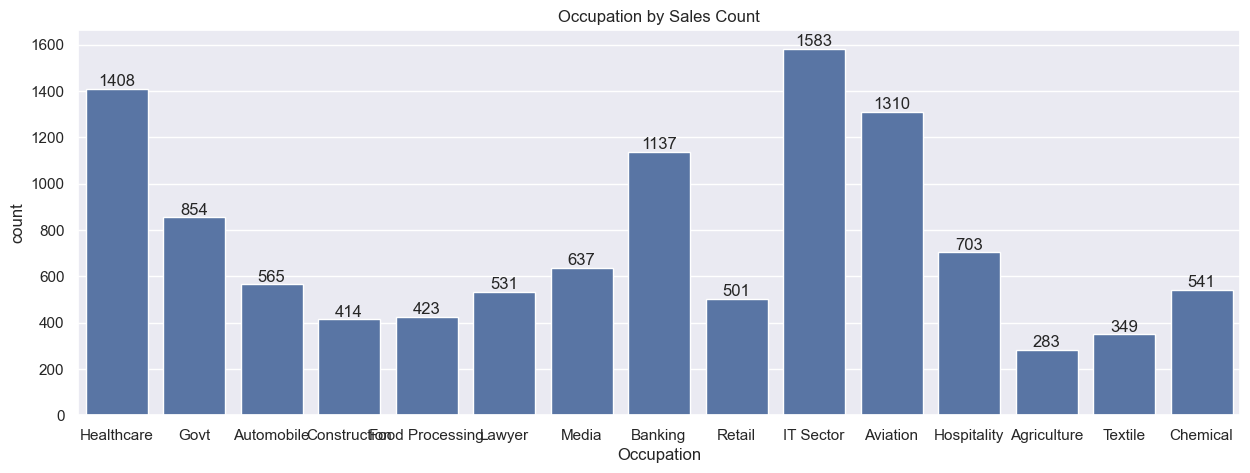

In [148]:
ax = sns.countplot(data = df , x = 'Occupation')

# Add bar labels
for bars in ax.containers:
    ax.bar_label(bars)

plt.title('Occupation by Sales Count')

In [150]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

Text(0.5, 1.0, 'Product Category Count')

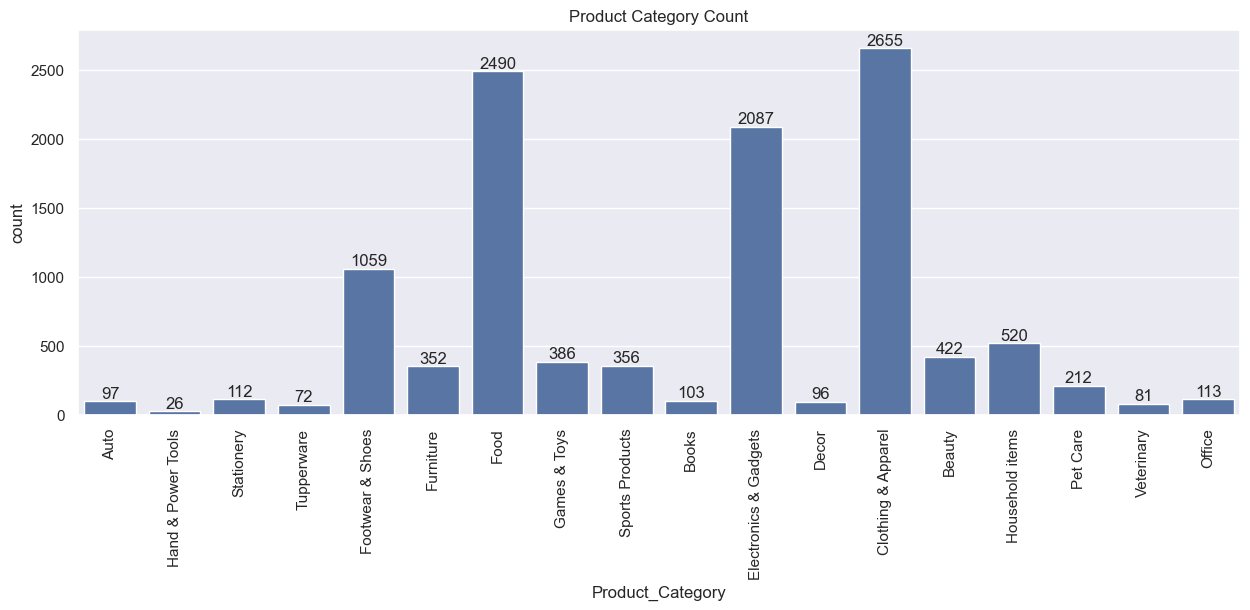

In [155]:
ax = sns.countplot(data = df , x = 'Product_Category')

# Add bar labels
for bars in ax.containers:
    ax.bar_label(bars)

plt.xticks(rotation=90)
plt.title('Product Category Count')

Text(0.5, 1.0, 'Product_Category by Sales Amount')

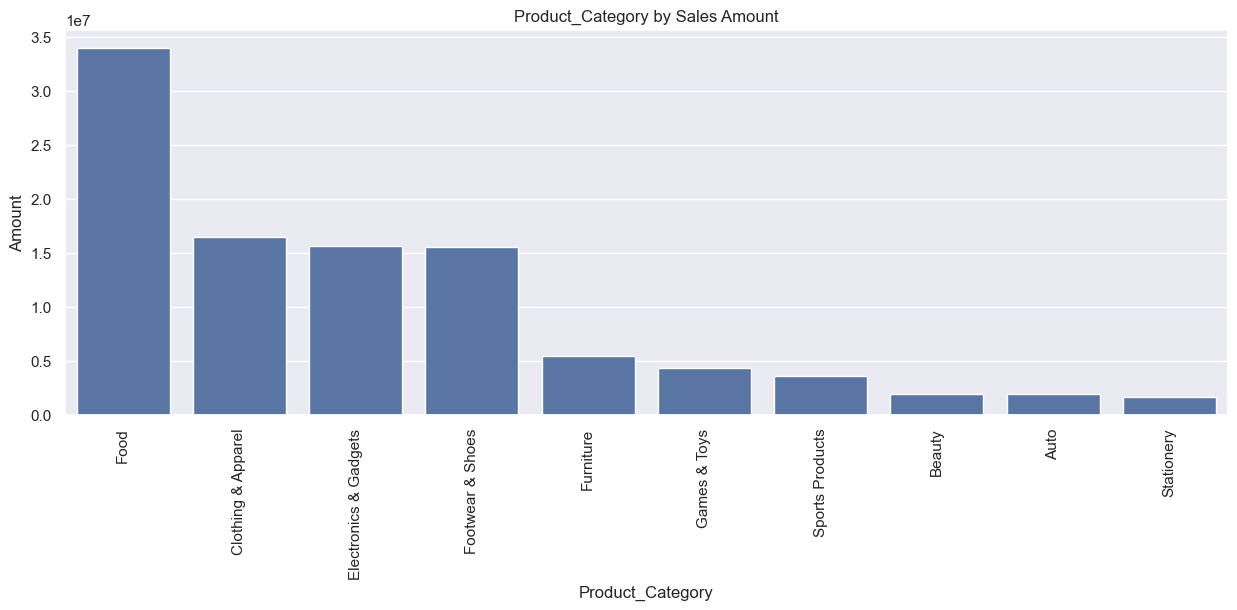

In [162]:
product_cat = df.groupby(['Product_Category'])['Amount'].sum().reset_index().sort_values(by ='Amount', ascending = False).head(10)

sns.barplot(x = 'Product_Category', y = 'Amount', data = product_cat)
# resize bar to show value
#sns.set(rc={'figure.figsize':(15,5)})
plt.xticks(rotation=90)
plt.title('Product_Category by Sales Amount')

In [ ]:
# Conclusion

# Married Females age_group 26-35 purchasing more, likely working in IT , Healthcare, Aviation Sector and most used product category Food, Clothing and Electronics.
    
